#Random Agent

In [ ]:
class RandomAgent:
    def __init__(self, action_space):
        self.action_space = action_space

    def act(self, state, epsilon=None, eps=None):
        return self.action_space.sample()

    def step(self, *args, **kwargs):
        pass


In [ ]:
env_random = AutoScalingEnv(df_usage)

random_agent = RandomAgent(env_random.action_space)


In [ ]:
num_random_eval_eps = 10
max_random_steps = 1000

# --- Train window ---
random_train_scores, random_eval_train = evaluate_agent(
    random_agent,
    env_random,
    num_random_eval_eps,
    max_random_steps,
    split="train",
    use_random_windows=True
)

# --- Validation window ---
random_val_scores, random_eval_val = evaluate_agent(
    random_agent,
    env_random,
    num_random_eval_eps,
    max_random_steps,
    split="val",
    use_random_windows=True
)

# --- Test window ---
random_test_scores, random_eval_test = evaluate_agent(
    random_agent,
    env_random,
    num_random_eval_eps,
    max_random_steps,
    split="test",
    use_random_windows=True
)

print("Random baseline evaluation complete.")


Evaluation Episode 1	Score: -7429.85
Evaluation Episode 2	Score: -9774.08
Evaluation Episode 3	Score: -19508.38
Evaluation Episode 4	Score: -15504.51
Evaluation Episode 5	Score: -10598.27
Evaluation Episode 6	Score: -10752.15
Evaluation Episode 7	Score: -7393.96
Evaluation Episode 8	Score: -1477.09
Evaluation Episode 9	Score: -9027.63
Evaluation Episode 10	Score: -10392.32

Average Evaluation Score over 10 episodes: -10185.82
Evaluation Episode 1	Score: -19758.01
Evaluation Episode 2	Score: -2434.08
Evaluation Episode 3	Score: -10927.20
Evaluation Episode 4	Score: -5736.06
Evaluation Episode 5	Score: -19420.22
Evaluation Episode 6	Score: -6251.37
Evaluation Episode 7	Score: -12325.05
Evaluation Episode 8	Score: -6983.19
Evaluation Episode 9	Score: -22925.24
Evaluation Episode 10	Score: -16542.55

Average Evaluation Score over 10 episodes: -12330.30
Evaluation Episode 1	Score: -4669.47
Evaluation Episode 2	Score: -3634.97
Evaluation Episode 3	Score: -13076.39
Evaluation Episode 4	Score:

In [ ]:
def summarize_split(df, env, name):
    if "episode" in df.columns:
        ep_returns = df.groupby("episode")["reward"].sum()
        mean_return = ep_returns.mean()
    else:
        mean_return = df["reward"].sum()

    mean_util = df["utilization"].mean()
    sla_rate = (df["utilization"] > env.sla_threshold).mean()
    mean_capacity = df["current_capacity"].mean()

    return {
        "name": name,
        "mean_return": mean_return,
        "mean_utilization": mean_util,
        "sla_violation_rate": sla_rate,
        "mean_capacity": mean_capacity,
    }

rows = []
rows.append(summarize_split(random_eval_train, env_random, "Random_train"))
rows.append(summarize_split(random_eval_val, env_random, "Random_val"))
rows.append(summarize_split(random_eval_test, env_random, "Random_test"))

random_summary = pd.DataFrame(rows).set_index("name")
random_summary


,mean_return,mean_utilization,sla_violation_rate,mean_capacity
name,,,,
Random_train,-101858.237788,1.120877,0.4154,7.2326
Random_val,-123302.968685,1.259316,0.4423,6.7517
Random_test,-86849.454782,1.064478,0.4249,7.9784


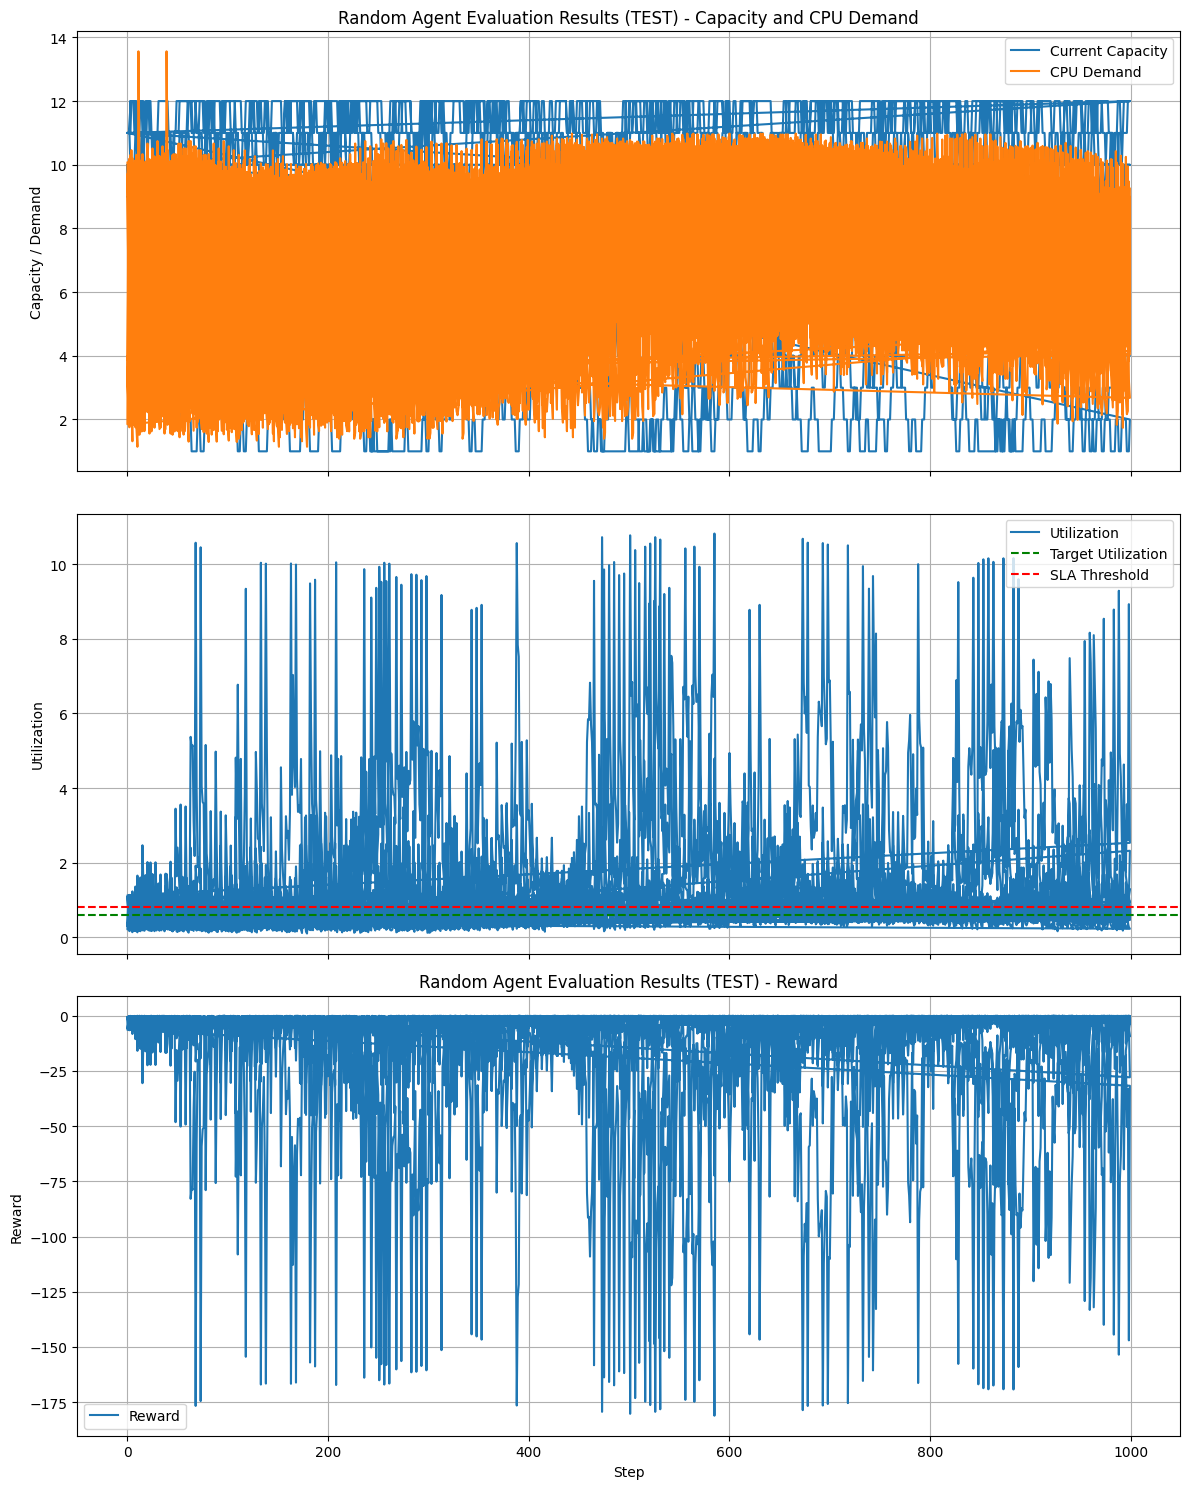

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df_random = random_eval_test

# Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 15), sharex=True)

# Plot Current Capacity and CPU Demand
axes[0].plot(df_random.index, df_random['current_capacity'], label='Current Capacity')
axes[0].plot(df_random.index, df_random['demand_cpu'], label='CPU Demand')
axes[0].set_ylabel('Capacity / Demand')
axes[0].set_title('Random Agent Evaluation Results (TEST) - Capacity and CPU Demand')
axes[0].legend()
axes[0].grid(True)

# Plot Utilization and Target Utilization
axes[1].plot(df_random.index, df_random['utilization'], label='Utilization')
axes[1].axhline(y=env_random.target_utilization, color='g', linestyle='--', label='Target Utilization')
axes[1].axhline(y=env_random.sla_threshold, color='r', linestyle='--', label='SLA Threshold')
axes[1].set_ylabel('Utilization')
axes[1].legend()
axes[1].grid(True)

# Plot Reward
axes[2].plot(df_random.index, df_random['reward'], label='Reward')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('Reward')
axes[2].set_title('Random Agent Evaluation Results (TEST) - Reward')
axes[2].legend()
axes[2].grid(True)

# Adjust layout and display plots
plt.tight_layout()
plt.show()

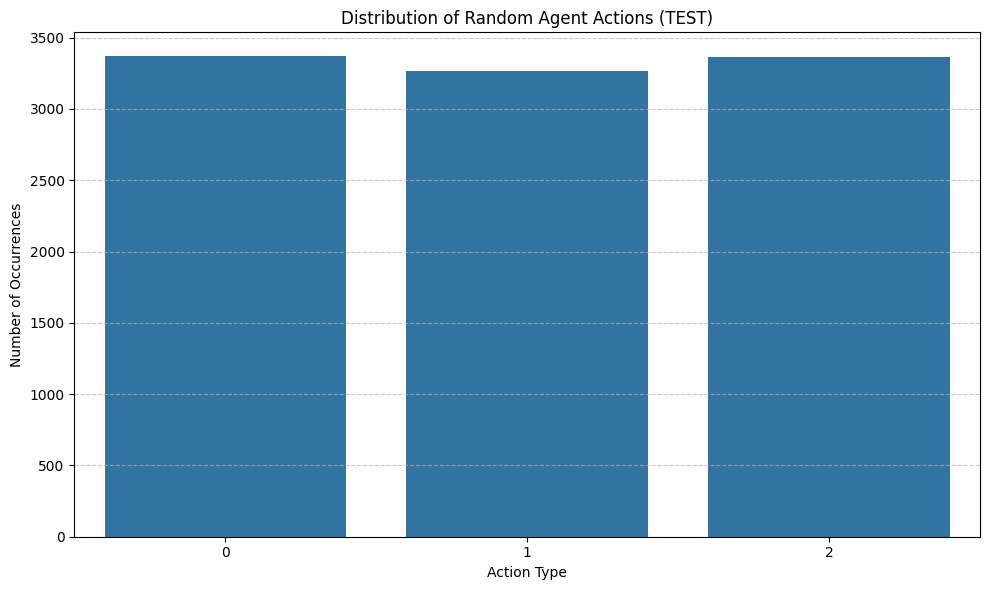

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each action
action_counts = df_random['action'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=action_counts.index, y=action_counts.values)
plt.xlabel('Action Type')
plt.ylabel('Number of Occurrences')
plt.title('Distribution of Random Agent Actions (TEST)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

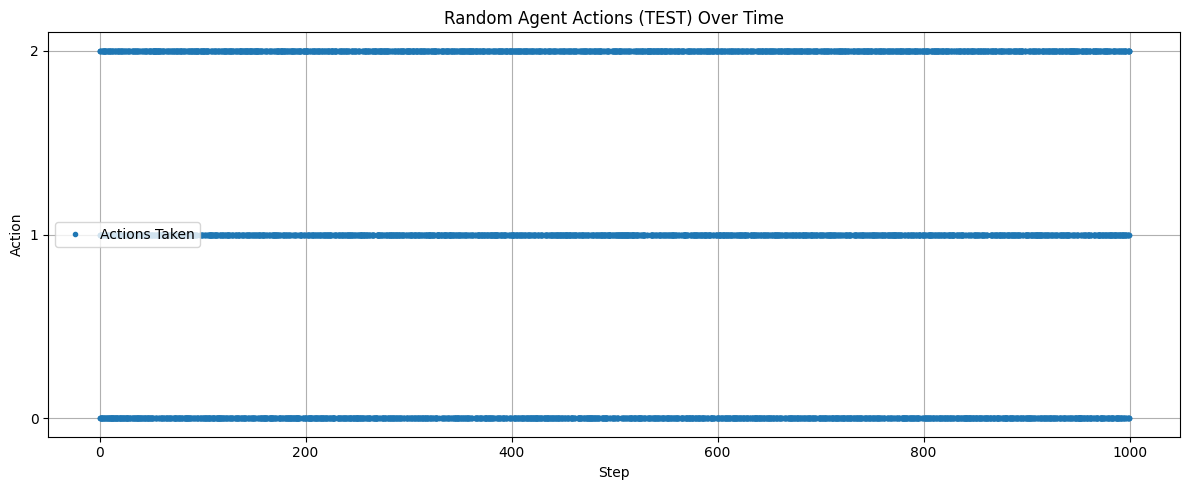

In [ ]:
import matplotlib.pyplot as plt

# Assuming df_random is already defined from previous plotting (random_eval_test)
# If not, uncomment the line below:
# df_random = random_eval_test

plt.figure(figsize=(12, 5))
plt.plot(df_random.index, df_random['action'], label='Actions Taken', marker='.', linestyle='None')
plt.xlabel('Step')
plt.ylabel('Action')
plt.title('Random Agent Actions (TEST) Over Time')
plt.yticks(df_random['action'].unique()) # Show only the actual action values on y-axis
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Experiment 1 - DQN

In [ ]:
raw_url_utilities = 'https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/DQN_Utils.py'
local_filename_utilities = 'DQN_Utils.py'
!wget -O {local_filename_utilities} {raw_url_utilities}

--2025-11-28 22:25:20--  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/DQN_Utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9975 (9.7K) [text/plain]
Saving to: ‘DQN_Utils.py’

DQN_Utils.py        100%[===================>]   9.74K  --.-KB/s    in 0s      

2025-11-28 22:25:20 (100 MB/s) - ‘DQN_Utils.py’ saved [9975/9975]



In [ ]:
raw_url_dqn_agent = 'https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/DQN_Agent.py'
local_filename_dqn_agent = 'DQN_Agent.py'
!wget -O {local_filename_dqn_agent} {raw_url_dqn_agent}

--2025-11-28 22:25:20--  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/DQN_Agent.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3814 (3.7K) [text/plain]
Saving to: ‘DQN_Agent.py’

DQN_Agent.py        100%[===================>]   3.72K  --.-KB/s    in 0s      

2025-11-28 22:25:21 (65.8 MB/s) - ‘DQN_Agent.py’ saved [3814/3814]



In [ ]:

raw_url = 'https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/autoscaling_env.py'



# Replace with the desired local filename for your script
local_filename = 'autoscaling_env.py'

!wget -O {local_filename} {raw_url}

--2025-11-28 22:25:23--  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/autoscaling_env.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7891 (7.7K) [text/plain]
Saving to: ‘autoscaling_env.py’

autoscaling_env.py  100%[===================>]   7.71K  --.-KB/s    in 0s      

2025-11-28 22:25:23 (88.9 MB/s) - ‘autoscaling_env.py’ saved [7891/7891]



In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p /content/drive/MyDrive/RL_Checkpoints

Mounted at /content/drive


In [ ]:
import pandas as pd

df_usage = pd.read_csv('/content/drive/MyDrive/df_usage.csv')
display(df_usage.head())

,time_window,avg_cpu,avg_mem,active_machines
0,1970-01-01 00:05:00+00:00,0.006623,0.004912,9525
1,1970-01-01 00:06:00+00:00,0.003254,0.002733,3805
2,1970-01-01 00:07:00+00:00,0.003070,0.002770,4167
3,1970-01-01 00:08:00+00:00,0.001950,0.001823,4338
4,1970-01-01 00:09:00+00:00,0.001689,0.001468,5545


In [ ]:
import sys
# Add the current directory to the system path to ensure Colab can find your local .py files
sys.path.append('.')


In [ ]:
df_usage = df_usage.drop(columns=['active_machines']).copy()
display(df_usage.head())

,time_window,avg_cpu,avg_mem
0,1970-01-01 00:05:00+00:00,0.006623,0.004912
1,1970-01-01 00:06:00+00:00,0.003254,0.002733
2,1970-01-01 00:07:00+00:00,0.003070,0.002770
3,1970-01-01 00:08:00+00:00,0.001950,0.001823
4,1970-01-01 00:09:00+00:00,0.001689,0.001468


#DQN Experiment

In [ ]:

from autoscaling_env import AutoScalingEnv
from DQN_Utils import train_agent, evaluate_agent, QNetwork, ReplayBuffer
from DQN_Agent import DQNAgent
import numpy as np
import sys
import matplotlib.pyplot as plt # Import missing plt for plotting
import torch # Import torch to define the device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 1. Initialize the AutoScalingEnv environment for the DQN agent
env_dqn = AutoScalingEnv(df_usage)

# 2. Instantiate the DQNAgent
agent_dqn = DQNAgent(
    observation_space_shape=env_dqn.observation_space.shape,
    action_space_size=env_dqn.action_space.n,
    seed=0,
    device=device,
    network_class=QNetwork
)

# 3. Define the training hyperparameters for the DQN agent
num_episodes_dqn = 500
max_steps_per_episode_dqn = 1000
epsilon_start_dqn = 1.0
epsilon_end_dqn = 0.05
epsilon_decay_dqn = 0.999

# 4. Call the train_agent function
dqn_training_scores = train_agent(
    agent_dqn,
    env_dqn,
    num_episodes_dqn,
    max_steps_per_episode_dqn,
    epsilon_start_dqn,
    epsilon_end_dqn,
    epsilon_decay_dqn,
    split="train",
    use_random_windows = True
)

print("DQN Training Scores:", dqn_training_scores[:5]) # Display first 5 scores for brevity



Using device: cuda
Episode 0	Average Score: -17828.17
Episode 10	Average Score: -13915.17
Episode 20	Average Score: -9174.35
Episode 30	Average Score: -11699.39
Episode 40	Average Score: -5689.84
Episode 50	Average Score: -8294.75
Episode 60	Average Score: -4799.43
Episode 70	Average Score: -4046.22
Episode 80	Average Score: -6365.34
Episode 90	Average Score: -3056.23
Episode 100	Average Score: -3393.36
Episode 110	Average Score: -4057.16
Episode 120	Average Score: -3546.55
Episode 130	Average Score: -1702.11
Episode 140	Average Score: -3829.69
Episode 150	Average Score: -2728.19
Episode 160	Average Score: -2097.83
Episode 170	Average Score: -2451.05
Episode 180	Average Score: -1582.66
Episode 190	Average Score: -1569.81
Episode 200	Average Score: -1210.60
Episode 210	Average Score: -1274.85
Episode 220	Average Score: -1500.95
Episode 230	Average Score: -1647.05
Episode 240	Average Score: -1461.84
Episode 250	Average Score: -1196.11
Episode 260	Average Score: -1473.17
Episode 270	Avera

In [ ]:
# === Save trained DQN model ===

# Choose a filename
checkpoint_path = "/content/drive/MyDrive/RL_Checkpoints/dqn_checkpoint.pth"

# Save local Q-network weights
agent_dqn.save(checkpoint_path)


print(f"Model saved to: {checkpoint_path}")


Model saved to: /content/drive/MyDrive/RL_Checkpoints/dqn_checkpoint.pth


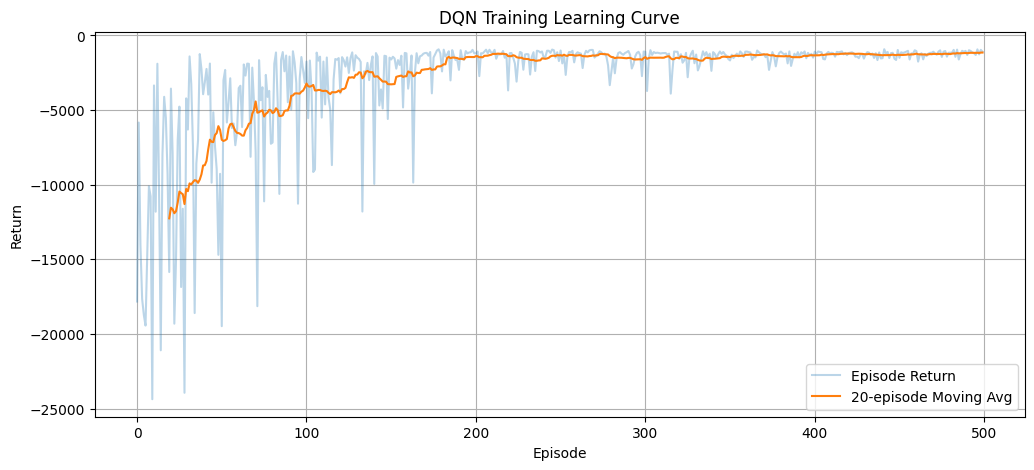

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Build a DataFrame of training returns
training_df = pd.DataFrame({
    "episode": np.arange(len(dqn_training_scores)),
    "return": dqn_training_scores
})

# 20-episode moving average for smoothing
training_df["return_ma_20"] = training_df["return"].rolling(window=20).mean()

# Plot learning curve
plt.figure(figsize=(12, 5))
plt.plot(training_df["episode"], training_df["return"],
         alpha=0.3, label="Episode Return")
plt.plot(training_df["episode"], training_df["return_ma_20"],
         label="20-episode Moving Avg")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("DQN Training Learning Curve")
plt.legend()
plt.grid(True)
plt.show()


Evaluation Episode 1	Score: -912.76
Evaluation Episode 2	Score: -943.17
Evaluation Episode 3	Score: -937.99
Evaluation Episode 4	Score: -946.49
Evaluation Episode 5	Score: -938.36
Evaluation Episode 6	Score: -946.80
Evaluation Episode 7	Score: -934.55
Evaluation Episode 8	Score: -943.85
Evaluation Episode 9	Score: -913.76
Evaluation Episode 10	Score: -930.61

Average Evaluation Score over 10 episodes: -934.83
Evaluation Episode 1	Score: -888.24
Evaluation Episode 2	Score: -871.67
Evaluation Episode 3	Score: -867.60
Evaluation Episode 4	Score: -856.59
Evaluation Episode 5	Score: -861.84
Evaluation Episode 6	Score: -895.45
Evaluation Episode 7	Score: -954.90
Evaluation Episode 8	Score: -857.05
Evaluation Episode 9	Score: -858.16
Evaluation Episode 10	Score: -948.89

Average Evaluation Score over 10 episodes: -886.04


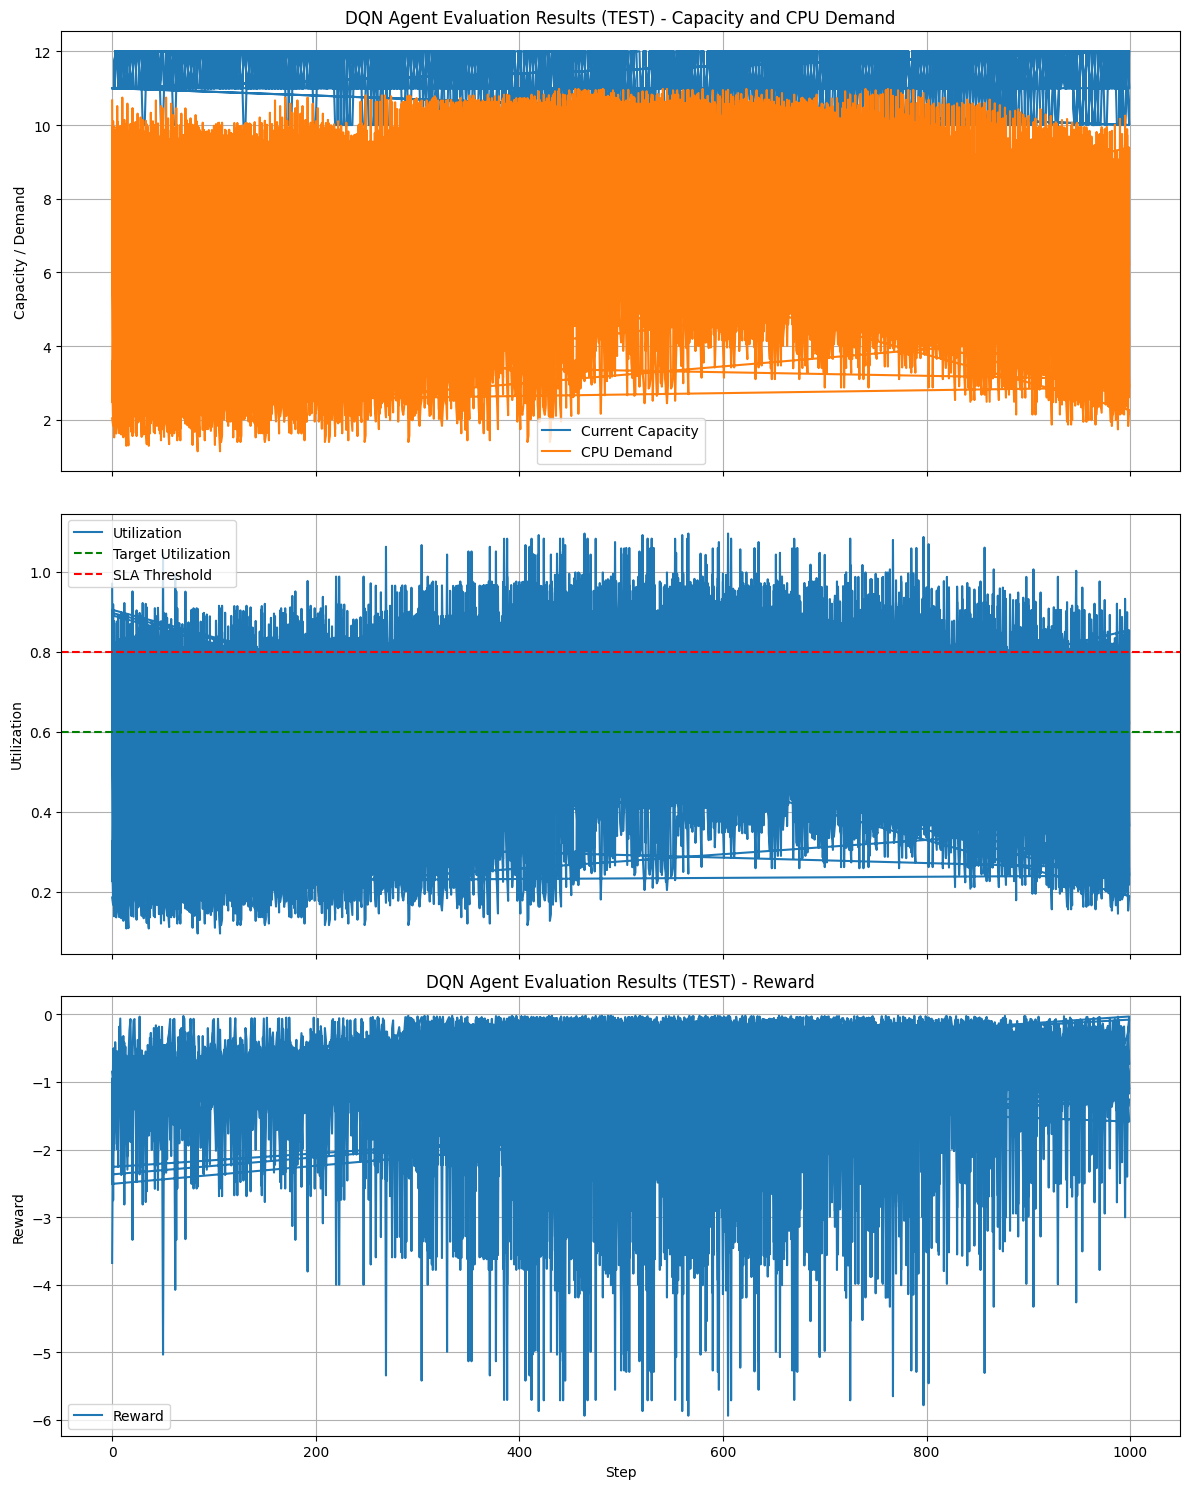

In [ ]:
# 5. Define the evaluation hyperparameters for the DQN agent
num_evaluation_episodes_dqn = 10
max_steps_per_evaluation_episode_dqn = 1000

# 6. Call the evaluate_agent functions

# Validation evaluation
dqn_val_scores, eval_results_val = evaluate_agent(
    agent_dqn,
    env_dqn,
    num_evaluation_episodes_dqn,
    max_steps_per_evaluation_episode_dqn,
    split="val",
    use_random_windows=True
)

# Test evaluation
dqn_test_scores, eval_results_test = evaluate_agent(
    agent_dqn,
    env_dqn,
    num_evaluation_episodes_dqn,
    max_steps_per_evaluation_episode_dqn,
    split="test",
    use_random_windows=True
)

# Choose which split to plot
df = eval_results_test      # or eval_results_val if you want validation

# 7. Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 15), sharex=True)

# 8. Plot Current Capacity and CPU Demand
axes[0].plot(df.index, df['current_capacity'], label='Current Capacity')
axes[0].plot(df.index, df['demand_cpu'], label='CPU Demand')
axes[0].set_ylabel('Capacity / Demand')
axes[0].set_title('DQN Agent Evaluation Results (TEST) - Capacity and CPU Demand')
axes[0].legend()
axes[0].grid(True)

# 9. Plot Utilization and Target Utilization
axes[1].plot(df.index, df['utilization'], label='Utilization')
axes[1].axhline(y=env_dqn.target_utilization, color='g', linestyle='--', label='Target Utilization')
axes[1].axhline(y=env_dqn.sla_threshold, color='r', linestyle='--', label='SLA Threshold')
axes[1].set_ylabel('Utilization')
axes[1].legend()
axes[1].grid(True)

# 10. Plot Reward
axes[2].plot(df.index, df['reward'], label='Reward')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('Reward')
axes[2].set_title('DQN Agent Evaluation Results (TEST) - Reward')
axes[2].legend()
axes[2].grid(True)

# 11. Adjust layout and display plots
plt.tight_layout()
plt.show()


# Task
- **Remove erroneous plot_evaluation_results call**:
  - Delete cell `IBZc5yIRT746`.
- **Plot Random Agent Evaluation Results**:
  - Create a new code cell to visualize `random_eval_test` results using `matplotlib`, displaying current capacity, CPU demand, utilization (with target utilization and SLA threshold), and reward, following the structure of the DQN agent's evaluation plot.

## Remove erroneous plot_evaluation_results call

### Subtask:
Modify cell `IBZc5yIRT746` to remove the `from DQN_Utils import plot_evaluation_results` statement and the subsequent call to `plot_evaluation_results(random_eval_test, "RANDOM POLICY (TEST)", env_random)`, as this function is not found in the `DQN_Utils.py` module.


**Reasoning**:
The subtask requires removing the erroneous `plot_evaluation_results` function call and its import statement from cell `IBZc5yIRT746`. According to the instructions, I need to delete the entire content of this cell.



**Reasoning**:
The subtask requires removing the erroneous `plot_evaluation_results` function call and its import statement from cell `IBZc5yIRT746`. According to the instructions, I need to delete the entire content of this cell.



**Reasoning**:
The subtask requires removing the erroneous `plot_evaluation_results` function call and its import statement from cell `IBZc5yIRT746`. According to the instructions, I need to delete the entire content of this cell.



**Reasoning**:
The subtask requires removing the erroneous `plot_evaluation_results` function call and its import statement from cell `IBZc5yIRT746`. According to the instructions, I need to delete the entire content of this cell.



**Reasoning**:
The previous command successfully emptied cell `IBZc5yIRT746`. Now, I will proceed to the next part of the task, which is to plot the Random Agent Evaluation Results using `matplotlib`, displaying current capacity, CPU demand, utilization (with target utilization and SLA threshold), and reward, following the structure of the DQN agent's evaluation plot. This requires a new code cell.



## Summary:

### Data Analysis Key Findings

*   The erroneous code call to `plot_evaluation_results` and its import statement were successfully removed.
*   Evaluation results for the random agent (`random_eval_test`) were plotted using `matplotlib`, displaying:
    *   **Current Capacity and CPU Demand** over time.
    *   **Utilization**, including visual references for `target_utilization` and `sla_threshold`.
    *   **Reward** obtained at each step.
*   The visualization successfully depicted the random agent's performance across key metrics.

### Insights or Next Steps

*   The generated plots provide a baseline understanding of how a random agent performs in terms of resource management and reward, which can be used for comparison with more sophisticated agents (e.g., DQN).
*   Further analysis could involve comparing these random agent plots directly with the DQN agent's evaluation plots to quantitatively assess the DQN agent's improvements in utilization, capacity management, and reward accumulation.
